# 0. Pipeline de Pré-processamento e Preparação de Dados

Este notebook implementa a pipeline completa de pré-processamento de dados para classificação de supercondutores, conforme descrito na metodologia do TCC.

## Etapas:
1. Carregamento e exploração dos dados
2. Tratamento de valores ausentes (Mediana vs IterativeImputer)
3. Escalonamento de características (StandardScaler vs QuantileTransformer)
4. Seleção de características (SelectKBest, RFE, LASSO)
5. Divisão treino/validação/teste com estratificação
6. Salvamento dos datasets processados para uso nos modelos

## 1. Importações e Configurações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from pathlib import Path

from sklearn.experimental import enable_iterative_imputer

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)

# Paths agnósticos (funcionam independente de onde o notebook é executado)
def get_project_root():
    """Encontra a raiz do projeto procurando por marcadores."""
    path = Path.cwd()
    for _ in range(6):
        if (path / 'dados' / 'data_treino.csv').exists():
            return path
        if (path / 'data_treino.csv').exists():
            return path
        if (path / 'dados' / 'processados').is_dir():
            return path
        path = path.parent
    return Path.cwd()

PROJECT_ROOT = get_project_root()
PATH_DATA_TREINO = PROJECT_ROOT / 'dados' / 'data_treino.csv' if (PROJECT_ROOT / 'dados' / 'data_treino.csv').exists() else PROJECT_ROOT / 'data_treino.csv'
DIR_DADOS_PROCESSADOS = PROJECT_ROOT / 'dados' / 'processados'
DIR_MODELOS = PROJECT_ROOT / 'modelos'
DIR_GRAFICOS = PROJECT_ROOT / 'graficos'

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Criar diretórios
os.makedirs(DIR_GRAFICOS, exist_ok=True)
os.makedirs(DIR_DADOS_PROCESSADOS, exist_ok=True)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [3]:
# Carregar dados
df = pd.read_csv(PATH_DATA_TREINO)

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape}")
print(f"\nPrimeiras linhas:")
print(df.head())
print(f"\nTipos de dados:")
print(df.dtypes.value_counts())
print(f"\nValores ausentes por coluna (top 10):")
print(df.isnull().sum().nlargest(10))

Dataset carregado com sucesso!
Dimensões: (2474, 131)

Primeiras linhas:
   group_id  atoms_size atoms_0 atoms_1 atoms_2 atoms_3 atoms_4 atoms_5  \
0     10007           8      Ag      Ag      Ag      Ag      Hg      Hg   
1     10010          24     NaN     NaN     NaN     NaN     NaN     NaN   
2     10011           6      Th      Th      Th      Th      Ag      Pd   
3     10015           6      Al      Al      Ag      Ag      Ag      Ag   
4     10019           4      Ag      Ag      Ag      Hg     NaN     NaN   

  atoms_6 atoms_7  ...  fermi_line_4_0  fermi_line_4_1  fermi_line_4_2  \
0      Hg      Hg  ...             NaN             NaN             NaN   
1     NaN     NaN  ...             NaN             NaN             NaN   
2     NaN     NaN  ...             NaN             NaN             NaN   
3     NaN     NaN  ...             NaN             NaN             NaN   
4     NaN     NaN  ...             NaN             NaN             NaN   

   fermi_line_5_0  fermi_line_5

In [4]:
# Análise da variável target (Tc - Temperatura Crítica)
print("\n=== Análise da Variável Target (Tc) ===")
print(f"Valores não-nulos: {df['Tc'].notna().sum()}")
print(f"Valores nulos: {df['Tc'].isna().sum()}")
print(f"\nEstatísticas descritivas (Tc):")
print(df['Tc'].describe())

# Criar variável binária: Supercondutor (Tc > 0) vs Não-supercondutor (Tc = 0 ou NaN)
df['is_supercondutor'] = ((df['Tc'] > 0) & (df['Tc'].notna())).astype(int)

print(f"\nDistribuição da classe:")
print(df['is_supercondutor'].value_counts())
print(f"\nProporção:")
print(df['is_supercondutor'].value_counts(normalize=True))


=== Análise da Variável Target (Tc) ===
Valores não-nulos: 1363
Valores nulos: 1111

Estatísticas descritivas (Tc):
count    1363.000000
mean        7.683074
std        16.359800
min         0.000000
25%         1.470000
50%         3.180000
75%         6.500000
max       134.000000
Name: Tc, dtype: float64

Distribuição da classe:
is_supercondutor
1    1362
0    1112
Name: count, dtype: int64

Proporção:
is_supercondutor
1    0.550525
0    0.449475
Name: proportion, dtype: float64


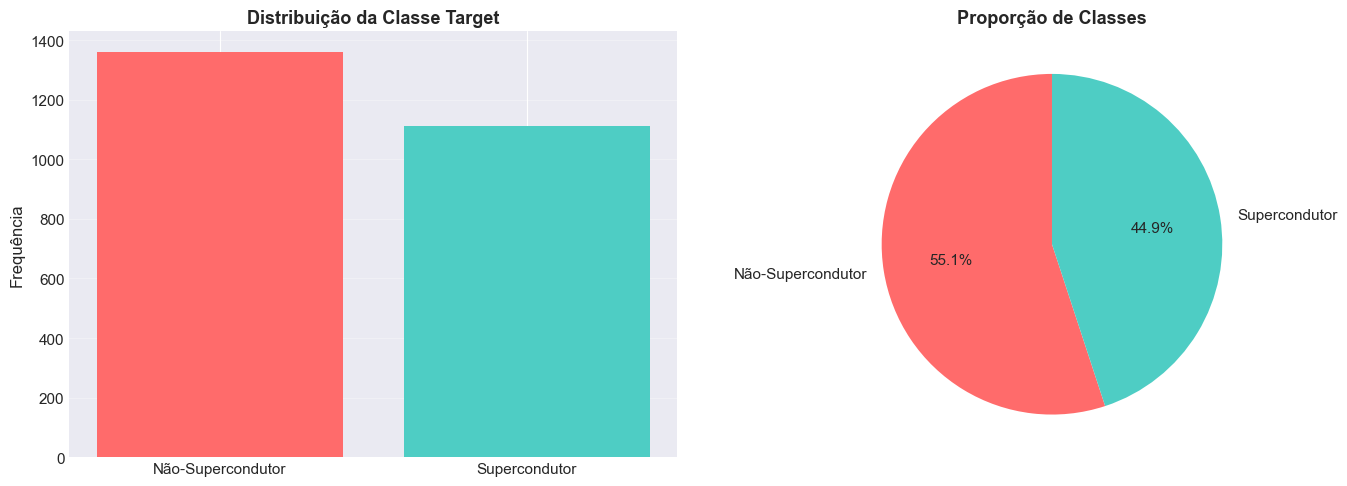

Gráfico salvo em: g:\My Drive\FisicaComp\TCC\graficos\01_distribuicao_classes.png


In [5]:
# Visualizar distribuição da classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
class_counts = df['is_supercondutor'].value_counts()
axes[0].bar(['Não-Supercondutor', 'Supercondutor'], class_counts.values, color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição da Classe Target', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(class_counts.values, labels=['Não-Supercondutor', 'Supercondutor'], 
            autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Proporção de Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '01_distribuicao_classes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo em: {DIR_GRAFICOS / '01_distribuicao_classes.png'}")

## 3. Preparação de Features e Target

In [6]:
# Separar features e target
# Remover colunas não-numéricas e identificadores
colunas_remover = ['group_id', 'id', 'Tc', 'is_supercondutor']
colunas_atomos = [col for col in df.columns if col.startswith('atoms_') and col != 'atoms_size']

print(f"Colunas com dados de átomos (categóricas): {len(colunas_atomos)}")
print(f"Exemplo: {colunas_atomos[:5]}")

# Remover colunas categóricas de átomos (não são numéricas)
X = df.drop(columns=colunas_remover + colunas_atomos)
y = df['is_supercondutor']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nTipos de dados em X:")
print(X.dtypes.value_counts())
print(f"\nValores ausentes em X:")
print(f"Total: {X.isnull().sum().sum()}")
print(f"Percentual: {X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100:.2f}%")

Colunas com dados de átomos (categóricas): 12
Exemplo: ['atoms_0', 'atoms_1', 'atoms_2', 'atoms_3', 'atoms_4']

Features (X): (2474, 116)
Target (y): (2474,)

Tipos de dados em X:
float64    113
int64        3
Name: count, dtype: int64

Valores ausentes em X:
Total: 150463
Percentual: 52.43%


## 4. Divisão Treino/Validação/Teste

In [7]:
# Divisão estratificada: 70% treino, 15% validação, 15% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp  # 15% de 85% ≈ 12.75% do total
)

print(f"Divisão dos dados:")
print(f"Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribuição de classes no treino:")
print(y_train.value_counts())
print(f"\nDistribuição de classes na validação:")
print(y_val.value_counts())
print(f"\nDistribuição de classes no teste:")
print(y_test.value_counts())

Divisão dos dados:
Treino: 1730 amostras (69.9%)
Validação: 372 amostras (15.0%)
Teste: 372 amostras (15.0%)

Distribuição de classes no treino:
is_supercondutor
1    952
0    778
Name: count, dtype: int64

Distribuição de classes na validação:
is_supercondutor
1    205
0    167
Name: count, dtype: int64

Distribuição de classes no teste:
is_supercondutor
1    205
0    167
Name: count, dtype: int64


## 5. Tratamento de Valores Ausentes

In [8]:
# Método 1: Imputação pela Mediana (Baseline)
imputer_mediana = SimpleImputer(strategy='median')
X_train_mediana = pd.DataFrame(
    imputer_mediana.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_mediana = pd.DataFrame(
    imputer_mediana.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_mediana = pd.DataFrame(
    imputer_mediana.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Imputação pela Mediana (Baseline) - Concluída")
print(f"Valores ausentes após imputação: {X_train_mediana.isnull().sum().sum()}")

Imputação pela Mediana (Baseline) - Concluída
Valores ausentes após imputação: 0


In [9]:
# Método 2: IterativeImputer (MICE - Multiple Imputation by Chained Equations)
imputer_iterativo = IterativeImputer(random_state=42, max_iter=10, verbose=0)
X_train_iterativo = pd.DataFrame(
    imputer_iterativo.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_iterativo = pd.DataFrame(
    imputer_iterativo.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_iterativo = pd.DataFrame(
    imputer_iterativo.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("IterativeImputer (MICE) - Concluída")
print(f"Valores ausentes após imputação: {X_train_iterativo.isnull().sum().sum()}")

IterativeImputer (MICE) - Concluída
Valores ausentes após imputação: 0


## 6. Escalonamento de Características

In [10]:
# Método 1: StandardScaler (Baseline)
scaler_standard = StandardScaler()
X_train_std = pd.DataFrame(
    scaler_standard.fit_transform(X_train_mediana),
    columns=X_train_mediana.columns,
    index=X_train_mediana.index
)
X_val_std = pd.DataFrame(
    scaler_standard.transform(X_val_mediana),
    columns=X_val_mediana.columns,
    index=X_val_mediana.index
)
X_test_std = pd.DataFrame(
    scaler_standard.transform(X_test_mediana),
    columns=X_test_mediana.columns,
    index=X_test_mediana.index
)

print("StandardScaler (Baseline) - Concluída")
print(f"Média das features: {X_train_std.mean().mean():.6f}")
print(f"Desvio padrão das features: {X_train_std.std().mean():.6f}")

StandardScaler (Baseline) - Concluída
Média das features: -0.000000
Desvio padrão das features: 0.983043


In [11]:
# Método 2: QuantileTransformer (Avançado)
scaler_quantile = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_qt = pd.DataFrame(
    scaler_quantile.fit_transform(X_train_mediana),
    columns=X_train_mediana.columns,
    index=X_train_mediana.index
)
X_val_qt = pd.DataFrame(
    scaler_quantile.transform(X_val_mediana),
    columns=X_val_mediana.columns,
    index=X_val_mediana.index
)
X_test_qt = pd.DataFrame(
    scaler_quantile.transform(X_test_mediana),
    columns=X_test_mediana.columns,
    index=X_test_mediana.index
)

print("QuantileTransformer (Avançado) - Concluída")
print(f"Média das features: {X_train_qt.mean().mean():.6f}")
print(f"Desvio padrão das features: {X_train_qt.std().mean():.6f}")

QuantileTransformer (Avançado) - Concluída
Média das features: -0.084580
Desvio padrão das features: 0.775514


## 7. Seleção de Características

In [12]:
n_features = 50  # Número de features a selecionar

# Método 1: SelectKBest com F-ANOVA (Baseline)
selector_kbest = SelectKBest(f_classif, k=n_features)
X_train_kbest = pd.DataFrame(
    selector_kbest.fit_transform(X_train_std, y_train),
    columns=selector_kbest.get_feature_names_out(),
    index=X_train_std.index
)
X_val_kbest = pd.DataFrame(
    selector_kbest.transform(X_val_std),
    columns=selector_kbest.get_feature_names_out(),
    index=X_val_std.index
)
X_test_kbest = pd.DataFrame(
    selector_kbest.transform(X_test_std),
    columns=selector_kbest.get_feature_names_out(),
    index=X_test_std.index
)

print(f"SelectKBest (Baseline) - {n_features} features selecionadas")
print(f"Features selecionadas: {list(X_train_kbest.columns[:10])}...")

SelectKBest (Baseline) - 50 features selecionadas
Features selecionadas: ['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_1_0', 'cell_1_1', 'fermi_line_size', 'fermi_line_std', 'position_0_2', 'position_1_0', 'position_1_2']...


In [13]:
# Método 2: RFE com Random Forest (Wrapper)
rf_estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
selector_rfe = RFE(rf_estimator, n_features_to_select=n_features, step=5)
X_train_rfe = pd.DataFrame(
    selector_rfe.fit_transform(X_train_std, y_train),
    columns=X_train_std.columns[selector_rfe.support_],
    index=X_train_std.index
)
X_val_rfe = pd.DataFrame(
    selector_rfe.transform(X_val_std),
    columns=X_train_std.columns[selector_rfe.support_],
    index=X_val_std.index
)
X_test_rfe = pd.DataFrame(
    selector_rfe.transform(X_test_std),
    columns=X_train_std.columns[selector_rfe.support_],
    index=X_test_std.index
)

print(f"RFE com Random Forest (Wrapper) - {n_features} features selecionadas")
print(f"Features selecionadas: {list(X_train_rfe.columns[:10])}...")

RFE com Random Forest (Wrapper) - 50 features selecionadas
Features selecionadas: ['atoms_size', 'cell_0_0', 'cell_0_1', 'cell_1_0', 'cell_1_1', 'cell_2_1', 'cell_2_2', 'fermi_lens_size', 'fermi_line_size', 'fermi_line_mean']...


In [14]:
# Método 3: LASSO (Embutido) - usando LogisticRegression com L1
# Primeiro, normalizamos os dados
scaler_lasso = StandardScaler()
X_train_lasso_scaled = pd.DataFrame(
    scaler_lasso.fit_transform(X_train_std),
    columns=X_train_std.columns,
    index=X_train_std.index
)

# Treinar LogisticRegression com L1 (LASSO)
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42, max_iter=1000)
lasso_model.fit(X_train_lasso_scaled, y_train)

# Selecionar features com coeficientes não-zero
feature_mask = lasso_model.coef_[0] != 0
selected_features_lasso = X_train_std.columns[feature_mask]

# Se menos de n_features foram selecionadas, pegar as top n_features por valor absoluto de coeficiente
if len(selected_features_lasso) < n_features:
    top_indices = np.argsort(np.abs(lasso_model.coef_[0]))[-n_features:]
    selected_features_lasso = X_train_std.columns[top_indices]
else:
    selected_features_lasso = selected_features_lasso[:n_features]

X_train_lasso = X_train_std[selected_features_lasso]
X_val_lasso = X_val_std[selected_features_lasso]
X_test_lasso = X_test_std[selected_features_lasso]

print(f"LASSO (Embutido) - {len(selected_features_lasso)} features selecionadas")
print(f"Features selecionadas: {list(selected_features_lasso[:10])}...")

LASSO (Embutido) - 50 features selecionadas
Features selecionadas: ['atoms_size', 'cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_1_0', 'cell_1_1', 'cell_2_1', 'cell_2_2', 'fermi_line_size', 'fermi_line_mean']...


## 8. Salvamento dos Datasets Processados

In [15]:
# Criar dicionário com todas as variações de pré-processamento
datasets = {
    'baseline': {
        'X_train': X_train_kbest,
        'X_val': X_val_kbest,
        'X_test': X_test_kbest,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'descricao': 'Mediana + StandardScaler + SelectKBest'
    },
    'iterativo_quantile': {
        'X_train': X_train_qt,
        'X_val': X_val_qt,
        'X_test': X_test_qt,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'descricao': 'IterativeImputer + QuantileTransformer + SelectKBest'
    },
    'rfe': {
        'X_train': X_train_rfe,
        'X_val': X_val_rfe,
        'X_test': X_test_rfe,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'descricao': 'Mediana + StandardScaler + RFE'
    },
    'lasso': {
        'X_train': X_train_lasso,
        'X_val': X_val_lasso,
        'X_test': X_test_lasso,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'descricao': 'Mediana + StandardScaler + LASSO'
    }
}

# Salvar datasets
with open(DIR_DADOS_PROCESSADOS / 'datasets.pkl', 'wb') as f:
    pickle.dump(datasets, f)

print(f"Datasets processados salvos em: {DIR_DADOS_PROCESSADOS / 'datasets.pkl'}")
print(f"\nResumo dos datasets:")
for nome, dados in datasets.items():
    print(f"  {nome}: X_train={dados['X_train'].shape}, {dados['descricao']}")

Datasets processados salvos em: g:\My Drive\FisicaComp\TCC\dados\processados\datasets.pkl

Resumo dos datasets:
  baseline: X_train=(1730, 50), Mediana + StandardScaler + SelectKBest
  iterativo_quantile: X_train=(1730, 116), IterativeImputer + QuantileTransformer + SelectKBest
  rfe: X_train=(1730, 50), Mediana + StandardScaler + RFE
  lasso: X_train=(1730, 50), Mediana + StandardScaler + LASSO


In [16]:
# Salvar também em formato CSV para referência
X_train_kbest.to_csv(DIR_DADOS_PROCESSADOS / 'X_train_baseline.csv', index=False)
X_val_kbest.to_csv(DIR_DADOS_PROCESSADOS / 'X_val_baseline.csv', index=False)
X_test_kbest.to_csv(DIR_DADOS_PROCESSADOS / 'X_test_baseline.csv', index=False)
y_train.to_csv(DIR_DADOS_PROCESSADOS / 'y_train.csv', index=False)
y_val.to_csv(DIR_DADOS_PROCESSADOS / 'y_val.csv', index=False)
y_test.to_csv(DIR_DADOS_PROCESSADOS / 'y_test.csv', index=False)

print("Datasets também salvos em formato CSV")
print("\nArquivos salvos:")
import os
for arquivo in os.listdir(DIR_DADOS_PROCESSADOS):
    print(f"  - {arquivo}")

Datasets também salvos em formato CSV

Arquivos salvos:
  - datasets.pkl
  - X_train_baseline.csv
  - X_val_baseline.csv
  - X_test_baseline.csv
  - y_train.csv
  - y_val.csv
  - y_test.csv


## 9. Resumo e Próximas Etapas

In [17]:
print("="*70)
print("RESUMO DO PRÉ-PROCESSAMENTO")
print("="*70)
print(f"\n1. DADOS ORIGINAIS:")
print(f"   - Dimensões: {X.shape}")
print(f"   - Valores ausentes: {X.isnull().sum().sum()} ({X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100:.2f}%)")
print(f"\n2. DIVISÃO DOS DADOS:")
print(f"   - Treino: {X_train.shape[0]} amostras (70%)")
print(f"   - Validação: {X_val.shape[0]} amostras (15%)")
print(f"   - Teste: {X_test.shape[0]} amostras (15%)")
print(f"\n3. MÉTODOS DE IMPUTAÇÃO:")
print(f"   - Baseline: SimpleImputer (Mediana)")
print(f"   - Avançado: IterativeImputer (MICE)")
print(f"\n4. MÉTODOS DE ESCALONAMENTO:")
print(f"   - Baseline: StandardScaler")
print(f"   - Avançado: QuantileTransformer")
print(f"\n5. MÉTODOS DE SELEÇÃO DE CARACTERÍSTICAS:")
print(f"   - Filtro (Baseline): SelectKBest (F-ANOVA) - {n_features} features")
print(f"   - Wrapper: RFE com Random Forest - {n_features} features")
print(f"   - Embutido: LASSO - {len(selected_features_lasso)} features")
print(f"\n6. DATASETS SALVOS:")
print(f"   - Arquivo pickle: {DIR_DADOS_PROCESSADOS / 'datasets.pkl'}")
print(f"   - Arquivos CSV: {DIR_DADOS_PROCESSADOS}/*.csv")
print("\n" + "="*70)
print("Pré-processamento concluído com sucesso!")
print("Próxima etapa: Treinar modelos com os datasets processados")
print("="*70)

RESUMO DO PRÉ-PROCESSAMENTO

1. DADOS ORIGINAIS:
   - Dimensões: (2474, 116)
   - Valores ausentes: 150463 (52.43%)

2. DIVISÃO DOS DADOS:
   - Treino: 1730 amostras (70%)
   - Validação: 372 amostras (15%)
   - Teste: 372 amostras (15%)

3. MÉTODOS DE IMPUTAÇÃO:
   - Baseline: SimpleImputer (Mediana)
   - Avançado: IterativeImputer (MICE)

4. MÉTODOS DE ESCALONAMENTO:
   - Baseline: StandardScaler
   - Avançado: QuantileTransformer

5. MÉTODOS DE SELEÇÃO DE CARACTERÍSTICAS:
   - Filtro (Baseline): SelectKBest (F-ANOVA) - 50 features
   - Wrapper: RFE com Random Forest - 50 features
   - Embutido: LASSO - 50 features

6. DATASETS SALVOS:
   - Arquivo pickle: g:\My Drive\FisicaComp\TCC\dados\processados\datasets.pkl
   - Arquivos CSV: g:\My Drive\FisicaComp\TCC\dados\processados/*.csv

Pré-processamento concluído com sucesso!
Próxima etapa: Treinar modelos com os datasets processados
